<a href="https://colab.research.google.com/github/Machoub/multilayer_perceptron/blob/main/mlp_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [229]:
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
np.random.seed(42)
# from google.colab import files
# uploaded = files.upload()

In [230]:
df = pd.read_csv('train_data.csv')
X = df.drop(columns=['diagnosis']).to_numpy().T
y = df['diagnosis'].to_numpy().reshape(-1, 1).T

y_one_hot = []
for label in y.flatten():
    if label == 0:
        y_one_hot.append([1, 0])
    elif label == 1:
        y_one_hot.append([0, 1])
y = np.array(y_one_hot).T

print(y)
print(y.shape)
print(X)
print(X.shape)

[[0 1 1 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 0 1 1 0 0 1 1
  1 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 0 0 0 0 0 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1
  0 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1
  0 0 0 1 1 1 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 0 1 1 0 0 1
  0 0 0 1 0 1 1 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0
  0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 0 1 0 1
  1 0 1 0 1 0 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 0
  0 1 1 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1
  0 0 0 1 0 0 0 1 1 1 1 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 1 0 1
  1 1 0 1 1 0 1 1 1 0 1 1 0 0 0 1 0 0 1 1 1 1 0 1 0 1 1 0 1 1 0 1 1 1 1 1
  1 1 0 1 1 1 1 0 0 0 1 0 1 0 1 1 0 0 1 1 0 1 0 0 0 1 1 0 1 1 0 1 1 0 1 0
  1 1 1 1 0 1 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 1
  1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0]
 [1 0 0 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0

In [231]:
# 1. Charger et nettoyer le fichier de test (Validation)
df_test = pd.read_csv('test_data.csv')

# --- Attention : Adapter selon ton fichier CSV ---
# Si ta colonne diagnosis est 'M'/'B', il faut mapper
if df_test['diagnosis'].dtype == 'object':
    df_test['diagnosis'] = df_test['diagnosis'].map({'M': 1, 'B': 0})

# 2. Séparer X et y
# On transpose (.T) pour avoir la forme (features, m_exemples) -> (30, m)
y_val = df_test['diagnosis'].values.reshape(1, -1)
X_val_raw = df_test.drop(columns=['diagnosis']).values.T

X_val = X_val_raw

print(f"X_val shape: {X_val.shape} | y_val shape: {y_val.shape}")

X_val shape: (30, 114) | y_val shape: (1, 114)


In [232]:
def sigmoid(z, derivative=False):
    if derivative:
        return z * (1 - z)
    return 1 / (1 + np.exp(-z))

def relu(Z, derivative=False):
    if derivative:
        return np.where(Z > 0, 1, 0)
    return np.maximum(0, Z)

In [233]:
def softmax(Z):

    e_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return e_Z / np.sum(e_Z, axis=0, keepdims=True)

In [234]:
def network_archi(X, y):
    n_input = X.shape[0]
    n_output = y.shape[0]
    return n_input,16, 8, n_output

print(network_archi(X, y))

(30, 16, 8, 2)


In [235]:
def define_model(X, y):
    n_input, n_h1, n_h2, n_output = network_archi(X, y)

    W1 = np.random.randn(n_h1, n_input)  * np.sqrt(2 / n_input)
    W2 = np.random.randn(n_h2, n_h1)    * np.sqrt(2 / n_h1)
    W3 = np.random.randn(n_output, n_h2) * np.sqrt(2 / n_h2)

    parameters = {
        'W1': W1, 'b1': np.zeros((n_h1, 1)),
        'W2': W2, 'b2': np.zeros((n_h2, 1)),
        'W3': W3, 'b3': np.zeros((n_output, 1)),
    }
    return parameters

params = define_model(X, y)
print(params)

{'W1': array([[ 0.12825104, -0.03569969,  0.16723246,  0.39324462, -0.06045814,
        -0.0604539 ,  0.407751  ,  0.1981508 , -0.12121777,  0.1400884 ,
        -0.11965393, -0.12025091,  0.06247439, -0.49400683, -0.44537187,
        -0.14518202, -0.26151187,  0.08113831, -0.23445081, -0.36465525,
         0.37842888, -0.05829519,  0.01743571, -0.3678684 , -0.14055902,
         0.02864009, -0.29718526,  0.09700481, -0.15508424, -0.075315  ],
       [-0.15535998,  0.47825617, -0.00348497, -0.27309979,  0.21238018,
        -0.31522047,  0.05392835, -0.50598465, -0.34293616,  0.05082935,
         0.19067125,  0.0442471 , -0.02986026, -0.07774464, -0.38175274,
        -0.18586298, -0.11893642,  0.27294779,  0.08872186, -0.45521501,
         0.08367812, -0.09942782, -0.17478051,  0.15793414,  0.26620293,
         0.24045549, -0.21668503, -0.07983829,  0.08553185,  0.25188467],
       [-0.12372226, -0.04793694, -0.28565446, -0.30885922,  0.20979327,
         0.35017967, -0.01859293,  0.25911

In [236]:
def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    W3, b3 = parameters['W3'], parameters['b3']

    Z1 = np.dot(W1, X) + b1;  A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2; A2 = relu(Z2)
    Z3 = np.dot(W3, A2) + b3; A3 = softmax(Z3)

    cache = {'Z1': Z1, 'A1': A1,
             'Z2': Z2, 'A2': A2,
             'Z3': Z3, 'A3': A3}
    return cache

In [237]:
shapes = forward_propagation(X, params)
print(shapes)

def backward_propagation(X, y, parameters, cache):
    m = X.shape[1]
    W2, W3 = parameters['W2'], parameters['W3']
    A1, A2, A3 = cache['A1'], cache['A2'], cache['A3']
    Z1, Z2 = cache['Z1'], cache['Z2']

    # Couche de sortie (softmax + cross-entropy -> dZ = A - y)
    dZ3 = A3 - y
    dW3 = (1/m) * np.dot(dZ3, A2.T)
    db3 = (1/m) * np.sum(dZ3, axis=1, keepdims=True)

    dZ2 = np.dot(W3.T, dZ3) * relu(Z2, derivative=True)
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2) * relu(Z1, derivative=True)
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

    return {'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2,
            'dW3': dW3, 'db3': db3}

def update_parameters(parameters, grads, lr):
    for key in ['W1', 'b1', 'W2', 'b2', 'W3', 'b3']:
        parameters[key] -= lr * grads['d' + key]
    return parameters

{'Z1': array([[ 1.18891989,  0.26632154, -1.10035336, ...,  0.80827583,
         0.95787   ,  0.37643802],
       [ 0.98669969, -0.16001465, -0.23468343, ...,  1.2725226 ,
         0.82357677, -0.26331093],
       [ 0.01142635, -0.93594891, -0.08168748, ..., -0.24828317,
         0.67617127,  1.61152243],
       ...,
       [-0.55495995,  0.59558171, -1.04810876, ..., -0.91527271,
        -0.48382243, -0.83584505],
       [ 0.33247753,  0.15435214, -0.53762321, ...,  1.49343532,
         0.25479101, -1.0618481 ],
       [-0.19552492,  0.48968588, -0.61113643, ..., -0.75128016,
        -0.56533937, -0.57521901]]), 'A1': array([[1.18891989, 0.26632154, 0.        , ..., 0.80827583, 0.95787   ,
        0.37643802],
       [0.98669969, 0.        , 0.        , ..., 1.2725226 , 0.82357677,
        0.        ],
       [0.01142635, 0.        , 0.        , ..., 0.        , 0.67617127,
        1.61152243],
       ...,
       [0.        , 0.59558171, 0.        , ..., 0.        , 0.        ,
      

In [238]:
def compute_cost(A3, Y):
    m = Y.shape[1]
    # Cross-Entropy formule
    cost = - (1/m) * np.sum(Y * np.log(A3 + 1e-8))
    return np.squeeze(cost) # S'assure que c'est un chiffre, pas un tableau

def compute_accuracy(A, Y):
    # A et Y sont de forme (2, 455)

    # On prend l'index du max (0 ou 1) pour chaque colonne
    predictions = np.argmax(A, axis=0)
    labels = np.argmax(Y, axis=0)

    # On compare : ça renvoie un tableau de True/False
    # np.mean calcule le pourcentage de True
    accuracy = np.mean(predictions == labels)

    return accuracy

In [239]:
def mlp(X, y, X_val, y_val, epochs=200, lr=0.1):
    params = define_model(X, y)
    history = {'train_cost': [], 'train_acc': [], 'val_acc': []}
    m = X.shape[1]
    for i in range(epochs):
        permutation = np.random.permutation(m)
        X = X[:, permutation]
        y = y[:, permutation]
        # Train
        cache = forward_propagation(X, params)
        cost  = compute_cost(cache['A3'], y)
        acc   = compute_accuracy(cache['A3'], y)

        # Validation
        val_cache = forward_propagation(X_val, params)
        val_acc   = compute_accuracy(val_cache['A3'], y_val)

        history['train_cost'].append(cost)
        history['train_acc'].append(acc)
        history['val_acc'].append(val_acc)

        grads  = backward_propagation(X, y, params, cache)
        params = update_parameters(params, grads, lr)

        if i % 10 == 0:
            print(f"Epoch {i:3d} | Loss: {cost:.4f} | Train: {acc:.2%} | Val: {val_acc:.2%}")

        # Early stopping si gap trop grand (overfitting)
        if acc - val_acc > 0.08:
            print(f"⚠️ Overfitting détecté à l'epoch {i}, arrêt.")
            break

    return params, history

(2, 114)
Epoch   0 | Loss: 1.7951 | Train: 62.64% | Val: 63.16%
Epoch  10 | Loss: 0.3224 | Train: 91.43% | Val: 90.35%
Epoch  20 | Loss: 0.2196 | Train: 92.97% | Val: 96.49%
Epoch  30 | Loss: 0.1625 | Train: 94.07% | Val: 96.49%
Epoch  40 | Loss: 0.1278 | Train: 95.82% | Val: 98.25%
Epoch  50 | Loss: 0.1085 | Train: 96.70% | Val: 97.37%
Epoch  60 | Loss: 0.0959 | Train: 96.92% | Val: 98.25%
Epoch  70 | Loss: 0.0873 | Train: 97.58% | Val: 98.25%
Epoch  80 | Loss: 0.0809 | Train: 97.58% | Val: 98.25%


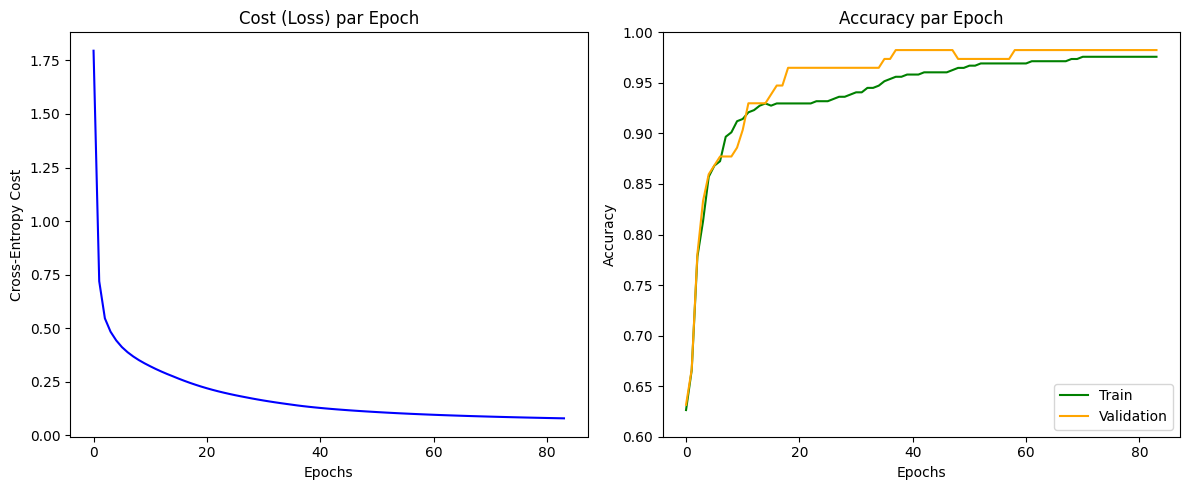

In [240]:
y_val_oh = np.eye(2)[y_val.flatten()].T

print(y_val_oh.shape)
model, history = mlp(X, y, X_val, y_val_oh, epochs=84, lr=0.1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : La Loss
ax1.plot(history['train_cost'], color='blue')
ax1.set_title('Cost (Loss) par Epoch')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Cross-Entropy Cost')

# Graphique 2 : Train vs Val Accuracy
ax2.plot(history['train_acc'], color='green', label='Train')
ax2.plot(history['val_acc'],   color='orange', label='Validation')
ax2.set_title('Accuracy par Epoch')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.6, 1.0)
ax2.legend()

plt.tight_layout()
plt.show()

In [241]:
np.save('saved_model.npy', model)
# ```

# **Mini-batch** — le sujet donne `batch_size=8` en exemple, tu fais du full-batch en ce moment.

# **Affichage epoch par epoch** dans le terminal comme ça :
# ```
# epoch 01/84 - loss: 0.6882 - val_loss: 0.6788

In [242]:
model = np.load('saved_model.npy', allow_pickle=True).item()
print(model)

{'W1': array([[ 3.96452817e-01, -1.71593558e-01, -2.72020710e-01,
        -5.31168122e-02,  5.83527491e-03,  2.54467251e-01,
        -4.65918900e-01,  3.73064867e-01, -6.96426444e-02,
        -1.39194263e-01, -2.80492489e-01, -4.33197943e-01,
         1.94160952e-01, -6.46753501e-04, -3.53286894e-01,
        -3.55207514e-01, -1.01950768e-01,  4.32189845e-01,
        -9.18462891e-02, -4.07442309e-01, -8.60190701e-02,
        -1.07333040e-01, -7.19021811e-01, -4.10757099e-02,
        -8.15820272e-02,  1.49554601e-01,  4.45715100e-01,
         2.71637018e-01, -1.09374060e-01, -3.14265928e-01],
       [ 5.51539157e-01, -1.41281111e-01, -1.06114880e-01,
        -1.24873359e-01,  3.33630095e-02, -6.77718981e-02,
        -1.91536294e-01, -2.16429209e-01, -6.10167275e-02,
        -1.11071619e-01, -2.77515556e-01,  4.87735279e-02,
        -1.42770989e-01,  2.99320518e-01, -6.28124302e-01,
         3.43090113e-01,  4.00619345e-01, -4.67256655e-01,
        -3.24464310e-02, -3.51167140e-02, -5.127

In [243]:
# ===============================
# 2. Charger les données de test
# ===============================
df_test = pd.read_csv('test_data.csv')
print(df_test.shape)

y_true = df_test['diagnosis'].values
X_test = df_test.drop(columns=['diagnosis']).to_numpy().T  # (30, 114)

# ===============================
# 3. Fonctions nécessaires
# ===============================
def relu(Z, derivative=False):
    if derivative:
        return np.where(Z > 0, 1, 0)
    return np.maximum(0, Z)

def softmax(Z):
    e_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return e_Z / np.sum(e_Z, axis=0, keepdims=True)

def forward_propagation(X, parameters):
    W1, b1 = parameters['W1'], parameters['b1']
    W2, b2 = parameters['W2'], parameters['b2']
    W3, b3 = parameters['W3'], parameters['b3']

    Z1 = np.dot(W1, X) + b1;  A1 = relu(Z1)
    Z2 = np.dot(W2, A1) + b2; A2 = relu(Z2)
    Z3 = np.dot(W3, A2) + b3; A3 = softmax(Z3)

    return A3

# ===============================
# 4. Prédiction
# ===============================
A_out = forward_propagation(X_test, model)

# A_out shape : (2, 114) → proba [benign, malignant]
predictions = np.argmax(A_out, axis=0)  # 0 = Benign, 1 = Malignant

# ===============================
# 5. Évaluation
# ===============================
accuracy = np.mean(predictions == y_true)

# Binary cross-entropy (formule du sujet)
proba_malignant = A_out[1, :]  # probabilité classe 1
bce = -np.mean(y_true * np.log(proba_malignant + 1e-8) +
               (1 - y_true) * np.log(1 - proba_malignant + 1e-8))

print(f"\n{'='*40}")
print(f"  Accuracy       : {accuracy:.2%}")
print(f"  Binary CE Loss : {bce:.4f}")
print(f"{'='*40}")

# ===============================
# 6. Détail par sample (optionnel)
# ===============================
labels = {0: 'Benign (B)', 1: 'Malignant (M)'}
print("\nAperçu des 10 premières prédictions :")
print(f"{'Index':<8} {'Prédit':<15} {'Réel':<15} {'Correct'}")
print("-" * 45)
for i in range(80):
    pred_label = labels[predictions[i]]
    true_label = labels[y_true[i]]
    correct    = "✅" if predictions[i] == y_true[i] else "❌"
    print(f"{i:<8} {pred_label:<15} {true_label:<15} {correct}")

(114, 31)

  Accuracy       : 98.25%
  Binary CE Loss : 0.0918

Aperçu des 10 premières prédictions :
Index    Prédit          Réel            Correct
---------------------------------------------
0        Benign (B)      Benign (B)      ✅
1        Malignant (M)   Malignant (M)   ✅
2        Benign (B)      Benign (B)      ✅
3        Malignant (M)   Malignant (M)   ✅
4        Benign (B)      Benign (B)      ✅
5        Benign (B)      Benign (B)      ✅
6        Malignant (M)   Malignant (M)   ✅
7        Benign (B)      Benign (B)      ✅
8        Benign (B)      Benign (B)      ✅
9        Benign (B)      Benign (B)      ✅
10       Malignant (M)   Malignant (M)   ✅
11       Benign (B)      Benign (B)      ✅
12       Malignant (M)   Malignant (M)   ✅
13       Benign (B)      Benign (B)      ✅
14       Benign (B)      Benign (B)      ✅
15       Benign (B)      Benign (B)      ✅
16       Benign (B)      Malignant (M)   ❌
17       Benign (B)      Benign (B)      ✅
18       Benign (B)      Beni